In [2]:
import re
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from bs4 import BeautifulSoup
from sklearn.model_selection import train_test_split

In [3]:
#Set up paths
project_root = Path.cwd().parent
data_raw = project_root / "data" / "raw"
data_processed = project_root / "data" / "processed"
results_figures = project_root / "results" / "figures"

print("Project root:", project_root)
print("Processed folder:", data_processed)
print("Figures folder:", results_figures)

Project root: c:\Users\STSC\Desktop\CS 671 Cyber Security\Project\ai-phishing-detection
Processed folder: c:\Users\STSC\Desktop\CS 671 Cyber Security\Project\ai-phishing-detection\data\processed
Figures folder: c:\Users\STSC\Desktop\CS 671 Cyber Security\Project\ai-phishing-detection\results\figures


In [ ]:
#Load the dataset created in 01_data_loading_and_inspection.ipynb

df = pd.read_csv(data_processed / "combined_raw_emails.csv")
print(df.shape)
print(df.columns)
df.head()

(82077, 2)
Index(['text', 'label'], dtype='object')


,text,label
0,hpl nom may 25 2001 see attached file hplno 52...,0
1,nom actual vols 24 th forwarded sabrae zajac h...,0
2,enron actuals march 30 april 1 201 estimated a...,0
3,hpl nom may 30 2001 see attached file hplno 53...,0
4,hpl nom june 1 2001 see attached file hplno 60...,0


In [ ]:
#Inspect raw text before cleaning.
print("Sample ham:\n")
print(df[df["label"] == 0]["text"].iloc[0][:1200])

print("\n" + "="*80 + "\n")

print("Sample phishing:\n")
print(df[df["label"] == 1]["text"].iloc[0][:1200])

Sample ham:

hpl nom may 25 2001 see attached file hplno 525 xls hplno 525 xls


Sample phishing:

link dwl g 510 802 11 g wireless pci lan adapter 39 85 39 85 dwl g 510 high speed 2 4 ghz 802 11 g wireless pci lan adapter ieee 802 11 g standardupto 54 mbpsoperating frequency range 2 4 ghz ideal solution enabling wireless networking capabilities desktops pcs home office dwl g 510 visit http www computron com deals link dwl g 510 802 11 g wireless pci lan adapter link g 510 wireless pci adapter featuring latest ieee 802 11 g wireless technology deliverincredibly fast data transfer 2 4 ghz frequency g 510 features 802 11 g standard backwards compatible existing 802 11 11 b products already also offers 64 128 bit wep encryption includes removable antenna driver cd get link g 510 wireless pci lan adapter today general features pci interface removable antenna 64 128 bit wep encryption link act led plug play one stop distributorjebel ali duty free zonedubai uae www computron com latest clear

In [6]:
print("Missing values:\n", df.isnull().sum())
print("\nDuplicates:", df.duplicated().sum())
print("\nEmpty text rows:", (df["text"].fillna("").astype(str).str.strip() == "").sum())

Missing values:
 text     0
label    0
dtype: int64

Duplicates: 0

Empty text rows: 0


In [7]:
df["text"] = df["text"].fillna("").astype(str)
df = df[df["text"].str.strip() != ""].drop_duplicates().copy()

print(df.shape)

(82077, 2)


In [8]:
#Cleaning function.
def clean_email_text(text):
    text = str(text)
    
    # Remove HTML tags if present
    text = BeautifulSoup(text, "html.parser").get_text(separator=" ")
    
    # Lowercase
    text = text.lower()
    
    # Replace URLs with a placeholder
    text = re.sub(r"http\S+|www\S+|https\S+", " URL ", text)
    
    # Replace email addresses with placeholder
    text = re.sub(r"\b[\w\.-]+@[\w\.-]+\.\w+\b", " EMAIL ", text)
    
    # Replace numbers with placeholder
    text = re.sub(r"\d+", " NUM ", text)
    
    # Keep only letters, spaces, and placeholders
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    
    # Normalize repeated whitespace
    text = re.sub(r"\s+", " ", text).strip()
    
    return text

In [9]:
df["clean_text"] = df["text"].apply(clean_email_text)

In [10]:
df[["text", "clean_text", "label"]].head(5)

,text,clean_text,label
0,hpl nom may 25 2001 see attached file hplno 52...,hpl nom may NUM NUM see attached file hplno NU...,0
1,nom actual vols 24 th forwarded sabrae zajac h...,nom actual vols NUM th forwarded sabrae zajac ...,0
2,enron actuals march 30 april 1 201 estimated a...,enron actuals march NUM april NUM NUM estimate...,0
3,hpl nom may 30 2001 see attached file hplno 53...,hpl nom may NUM NUM see attached file hplno NU...,0
4,hpl nom june 1 2001 see attached file hplno 60...,hpl nom june NUM NUM see attached file hplno N...,0


In [11]:
print("Original:\n")
print(df["text"].iloc[1][:1000])

print("\n" + "="*80 + "\n")

print("Cleaned:\n")
print(df["clean_text"].iloc[1][:1000])

Original:

nom actual vols 24 th forwarded sabrae zajac hou ect 05 30 2001 12 07 pm enron capital trade resources corp eileen ponton 05 29 2001 08 37 davilal txu com cstonel txu com mjones 7 txu com hpl scheduling enron com liz bellamy enron com szajac enron com cc subject nom actual vols 24 th agree nomination 33 750 forwarded eileen ponton houston pefs pec 05 29 01 08 36 charlie stone eileen ponton melissa jones com hpl scheduling enron com liz bellamy enron com szajac enron com 05 25 01 subject nom actual vols 24 th 04 23 pm agree nominated volume records reflect following nom schedule 30 rate eff 0900 hrs hour beginning 1400 hrs 6 250 60 rate eff 1400 hrs hour beginning 1700 hrs 7 500 30 rate eff 1700 hrs hour beginning 0900 hrs 20 000 total nominated 33 750 please review source data let us know agree thanks ccs eileen ponton 05 25 2001 04 06 50 pm david avila lsp enserch us tu charlie stone energy txu tu melissa jones energy txu tu hpl scheduling enron com liz bellamy enron com sz

In [12]:
#Remove rows with unusable cleaned text
df = df[df["clean_text"].str.strip() != ""].copy()
df["clean_length"] = df["clean_text"].str.len()

print(df.shape)
print(df["clean_length"].describe())

(82077, 4)
count    8.207700e+04
mean     1.225973e+03
std      2.112291e+04
min      2.000000e+00
25%      2.650000e+02
50%      5.300000e+02
75%      1.297000e+03
max      5.915823e+06
Name: clean_length, dtype: float64


In [13]:
df = df[df["clean_length"] > 10].copy()
print(df.shape)

(82069, 4)


label
1    42838
0    39231
Name: count, dtype: int64


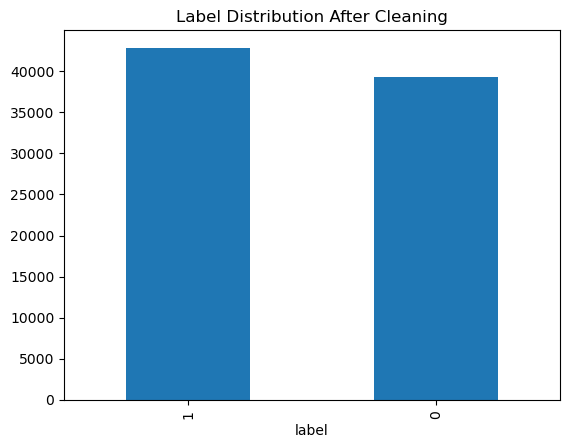

In [14]:
#Inspect class balance again
print(df["label"].value_counts())
df["label"].value_counts().plot(kind="bar", title="Label Distribution After Cleaning")
plt.show()

In [15]:
df.groupby("label")["clean_length"].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,39231.0,1466.454589,3582.524590,12.0,382.0,732.0,1435.0,167148.0
1,42838.0,1005.968369,29034.871533,12.0,222.0,381.0,1032.0,5915823.0


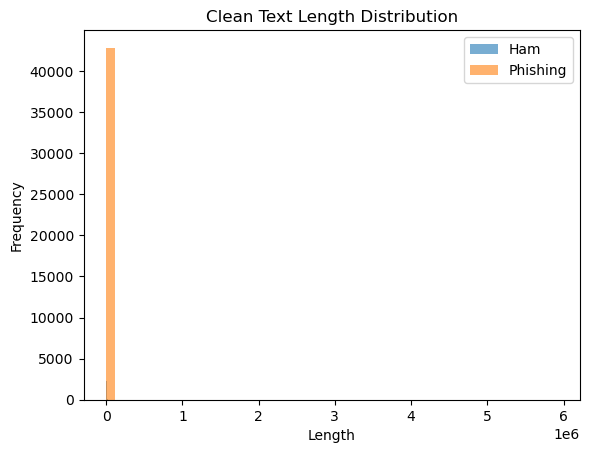

In [16]:
df[df["label"] == 0]["clean_length"].plot(kind="hist", bins=50, alpha=0.6, label="Ham")
df[df["label"] == 1]["clean_length"].plot(kind="hist", bins=50, alpha=0.6, label="Phishing")
plt.legend()
plt.title("Clean Text Length Distribution")
plt.xlabel("Length")
plt.show()


In [17]:
#Save the cleaned full dataset
cleaned_output = data_processed / "emails_cleaned_full.csv"
df.to_csv(cleaned_output, index=False)
print("Saved cleaned full dataset to:", cleaned_output)

Saved cleaned full dataset to: c:\Users\STSC\Desktop\CS 671 Cyber Security\Project\ai-phishing-detection\data\processed\emails_cleaned_full.csv


In [18]:
#Prepare features and labels for splitting
model_df = df[["clean_text", "label"]].copy()
print(model_df.shape)
model_df.head()

(82069, 2)


,clean_text,label
0,hpl nom may NUM NUM see attached file hplno NU...,0
1,nom actual vols NUM th forwarded sabrae zajac ...,0
2,enron actuals march NUM april NUM NUM estimate...,0
3,hpl nom may NUM NUM see attached file hplno NU...,0
4,hpl nom june NUM NUM see attached file hplno N...,0


In [19]:
#Split into train and test sets
X = model_df["clean_text"]
y = model_df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [20]:
#Rebuild train and test dataframes
train_df = pd.DataFrame({
    "clean_text": X_train,
    "label": y_train
}).reset_index(drop=True)

test_df = pd.DataFrame({
    "clean_text": X_test,
    "label": y_test
}).reset_index(drop=True)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

print("\nTrain label distribution:")
print(train_df["label"].value_counts(normalize=True))

print("\nTest label distribution:")
print(test_df["label"].value_counts(normalize=True))

Train shape: (65655, 2)
Test shape: (16414, 2)

Train label distribution:
label
1    0.521971
0    0.478029
Name: proportion, dtype: float64

Test label distribution:
label
1    0.521993
0    0.478007
Name: proportion, dtype: float64


In [21]:
#Save train and test files
train_path = data_processed / "train_emails.csv"
test_path = data_processed / "test_emails.csv"

train_df.to_csv(train_path, index=False)
test_df.to_csv(test_path, index=False)

print("Saved train set to:", train_path)
print("Saved test set to:", test_path)

Saved train set to: c:\Users\STSC\Desktop\CS 671 Cyber Security\Project\ai-phishing-detection\data\processed\train_emails.csv
Saved test set to: c:\Users\STSC\Desktop\CS 671 Cyber Security\Project\ai-phishing-detection\data\processed\test_emails.csv


## Preprocessing decisions

- Lowercased all text
- Removed HTML tags
- Replaced URLs with URL placeholder
- Replaced email addresses with EMAIL placeholder (Instead of remembering a specific email addr, model may memorize it instead of learning from it).
- Replaced numbers with NUM placeholder
- Preserved word-level structure for phishing detection
- Split data into 80% train and 20% test using stratified sampling